# Task 0 — Data Exploratory Analysis (EDA) sul Dataset QEvasion

Questo notebook analizza il dataset utilizzato per il fine-tuning di Llama 3.1.
L'obiettivo è estrarre statistiche utili sulle distribuzioni delle etichette (Clarity ed Evasion), calcolare la lunghezza media dei testi e visualizzare la correlazione tra le tecniche di evasione e le macro-categorie di chiarezza.

In [ ]:
# ============================================================
# CELLA 1 — Setup e Importazione Librerie
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
import sys
from pathlib import Path

# Stile dei grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Configurazione dei percorsi e rilevamento ambiente (Colab / Locale)
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Ambiente Google Colab rilevato. Google Drive montato con successo.")

    # Percorso base su Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"

except ImportError:
    print("Ambiente locale rilevato.")

    # Percorso base locale (impostato alla root del progetto corrente)
    BASE_DIR = "."

REPO_DIR = os.path.join(BASE_DIR, "CLARITY")

# Percorso per il salvataggio dei grafici e dei risultati dell'analisi
ANALYSIS_DIR = os.path.join(REPO_DIR, "analisi_dataset")
os.makedirs(ANALYSIS_DIR, exist_ok=True)
print(f"Directory di output impostata su: {ANALYSIS_DIR}")


PROJECT_ROOT = Path(REPO_DIR).resolve()  
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
Ambiente Google Colab rilevato. Google Drive montato con successo.
Directory di output impostata su: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


In [ ]:
# ============================================================
# CELLA 2 — Caricamento Dataset e Conversione in Pandas
# ============================================================
from src.data.dataset_loader import load_and_split_dataset

raw_ds = load_and_split_dataset(seed=42, verbose=True)

dataset_train = raw_ds['train']
dataset_test  = raw_ds['test']

# Conversione in DataFrame Pandas per l'analisi statistica
df_train = dataset_train.to_pandas()
df_test  = dataset_test.to_pandas()

# Aggiunta colonna per l'identificazione dello split
df_train['split'] = 'Train'
df_test['split'] = 'Test'

# Unione in un singolo DataFrame
df_all = pd.concat([df_train, df_test], ignore_index=True)

print("Dataset caricato con successo.")
print(f" - Esempi in Train: {len(df_train)}")
print(f" - Esempi in Test:  {len(df_test)}")
print(f" - Totale Esempi:   {len(df_all)}\n")

display(df_all.head(3))

Caricamento dataset in corso dai seguenti percorsi:
 -> /content/drive/MyDrive/progettoLLM/CLARITY/dataset/QEvasion/train
 -> /content/drive/MyDrive/progettoLLM/CLARITY/dataset/QEvasion/test
Dataset caricato con successo.
 - Esempi in Train: 3448
 - Esempi in Test:  308
 - Totale Esempi:   3756



,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,split
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,...,None,None,None,False,False,False,0,Clear Reply,Explicit,Train
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,...,None,None,None,False,False,False,1,Ambivalent,General,Train
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,...,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer,Train


--- Distribuzione Etichette di Chiarezza (Task 1) ---
clarity_label
Ambivalent         2246
Clear Reply        1131
Clear Non-Reply     379
Name: count, dtype: int64

Percentuali:
clarity_label
Ambivalent         59.797657
Clear Reply        30.111821
Clear Non-Reply    10.090522
Name: proportion, dtype: float64


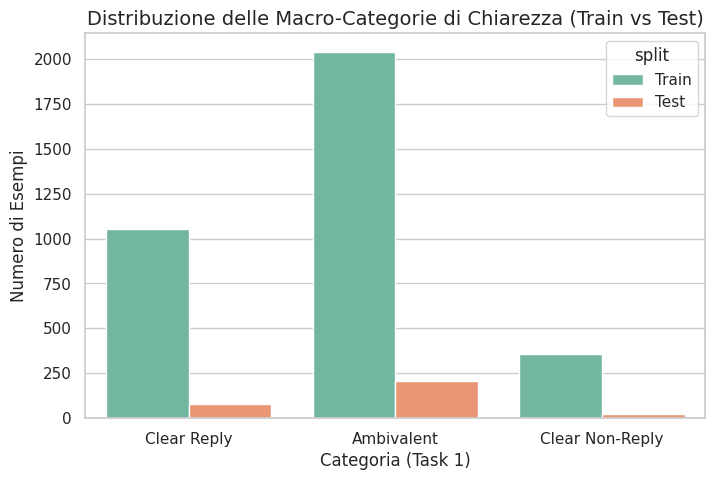

In [ ]:
# ============================================================
# CELLA 3 — Distribuzione Macro-Categorie (Task 1: Clarity)
# ============================================================

print("--- Distribuzione Etichette di Chiarezza (Task 1) ---")
clarity_counts = df_all['clarity_label'].value_counts()
print(clarity_counts)
print(f"\nPercentuali:\n{df_all['clarity_label'].value_counts(normalize=True) * 100}")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_all, x='clarity_label', hue='split', palette='Set2',
                   order=["Clear Reply", "Ambivalent", "Clear Non-Reply"])

plt.title('Distribuzione delle Macro-Categorie di Chiarezza (Train vs Test)', fontsize=14)
plt.xlabel('Categoria (Task 1)', fontsize=12)
plt.ylabel('Numero di Esempi', fontsize=12)

# Salva il grafico
plt.savefig(f"{ANALYSIS_DIR}/distribuzione_clarity.png", bbox_inches='tight', dpi=300)
plt.show()

--- Distribuzione Tecniche di Evasione (Task 2) ---
evasion_label
Explicit               1052
Dodging                 706
Implicit                488
General                 386
Deflection              381
                        308
Declining to answer     145
Claims ignorance        119
Clarification            92
Partial/half-answer      79
Name: count, dtype: int64


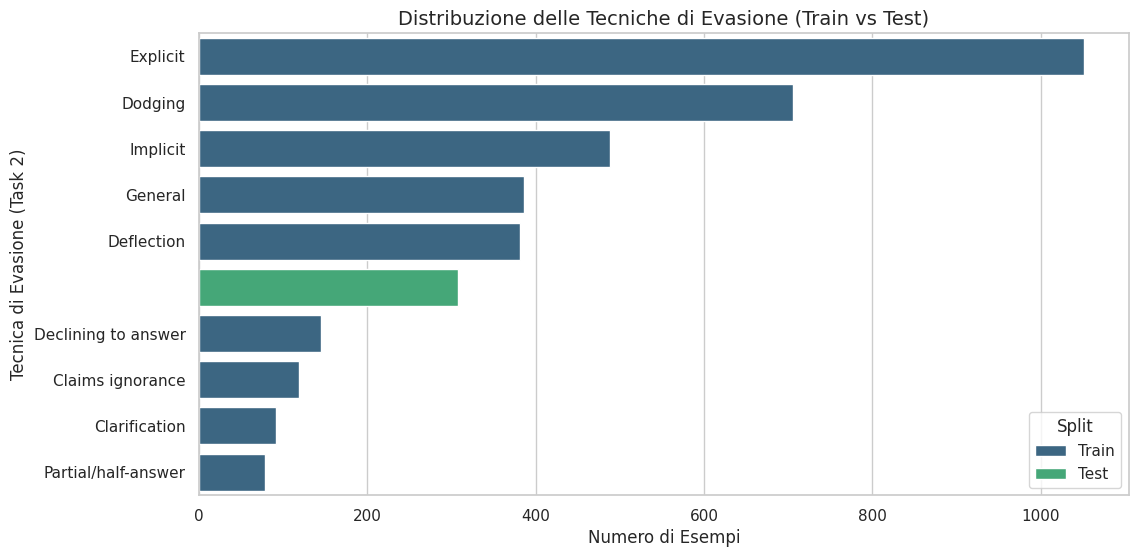

In [ ]:
# ============================================================
# CELLA 4 — Distribuzione Tecniche di Evasione (Task 2)
# ============================================================

print("--- Distribuzione Tecniche di Evasione (Task 2) ---")
evasion_counts = df_all['evasion_label'].value_counts()
print(evasion_counts)

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_all, y='evasion_label', hue='split', palette='viridis',
                   order=evasion_counts.index)

plt.title('Distribuzione delle Tecniche di Evasione (Train vs Test)', fontsize=14)
plt.xlabel('Numero di Esempi', fontsize=12)
plt.ylabel('Tecnica di Evasione (Task 2)', fontsize=12)
plt.legend(title='Split', loc='lower right')

plt.savefig(f"{ANALYSIS_DIR}/distribuzione_evasion.png", bbox_inches='tight', dpi=300)
plt.show()

--- Statistiche Lunghezza Testi (Numero di Parole) ---


,word_count_question,word_count_answer
count,3756.000000,3756.000000
mean,61.256922,296.256656
std,58.024103,298.274560
min,3.000000,1.000000
25%,23.000000,62.000000
50%,51.000000,213.000000
75%,81.000000,440.000000
max,780.000000,2117.000000


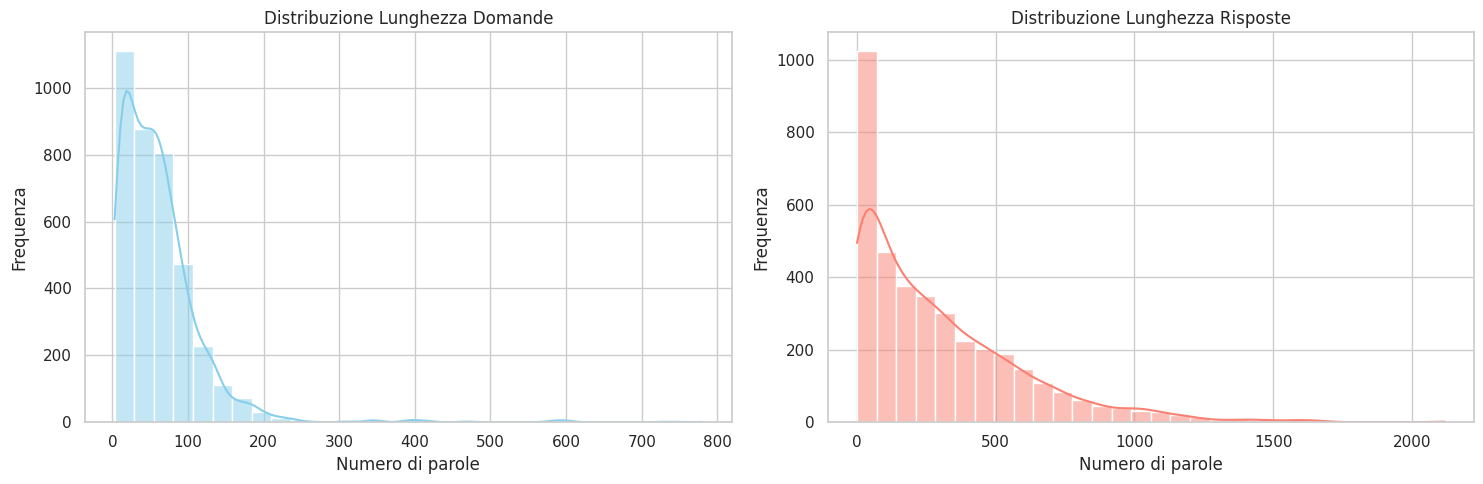

In [ ]:
# ============================================================
# CELLA 5 — Analisi della Lunghezza dei Testi (Word Count)
# ============================================================

# Calcoliamo il numero di parole per domanda e risposta
df_all['word_count_question'] = df_all['interview_question'].apply(lambda x: len(str(x).split()))
df_all['word_count_answer']   = df_all['interview_answer'].apply(lambda x: len(str(x).split()))

print("--- Statistiche Lunghezza Testi (Numero di Parole) ---")
display(df_all[['word_count_question', 'word_count_answer']].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma Domande
sns.histplot(df_all['word_count_question'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribuzione Lunghezza Domande')
axes[0].set_xlabel('Numero di parole')
axes[0].set_ylabel('Frequenza')

# Istogramma Risposte
sns.histplot(df_all['word_count_answer'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribuzione Lunghezza Risposte')
axes[1].set_xlabel('Numero di parole')
axes[1].set_ylabel('Frequenza')

plt.tight_layout()
plt.savefig(f"{ANALYSIS_DIR}/lunghezza_testi.png", bbox_inches='tight', dpi=300)
plt.show()

--- Crosstab: Evasion Label vs Clarity Label ---


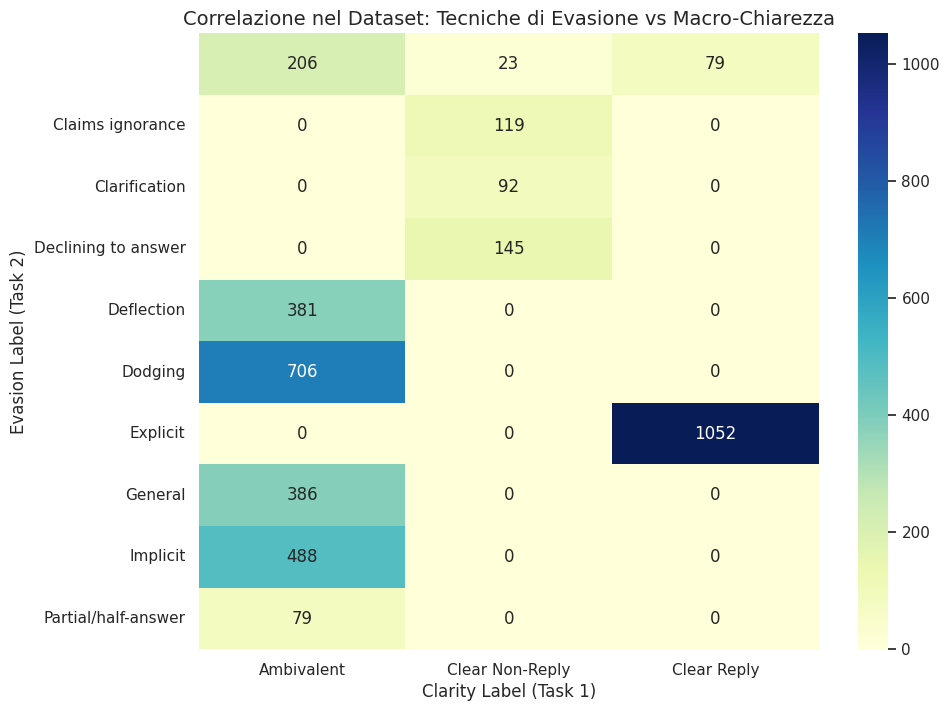

Analisi completata! Grafici e dati salvati in: /content/drive/MyDrive/progettoLLM/CLARITY/analisi_dataset


In [ ]:
# ============================================================
# CELLA 6 — Matrice di Correlazione (Task 2 -> Task 1)
# ============================================================
# Vogliamo vedere esattamente come le etichette di Evasione si
# traducono in etichette di Chiarezza nel Dataset Reale (Ground Truth).

print("--- Crosstab: Evasion Label vs Clarity Label ---")
crosstab_df = pd.crosstab(df_all['evasion_label'], df_all['clarity_label'])

plt.figure(figsize=(10, 8))
sns.heatmap(crosstab_df, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Correlazione nel Dataset: Tecniche di Evasione vs Macro-Chiarezza', fontsize=14)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Evasion Label (Task 2)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_correlazione_t1_t2.png", bbox_inches='tight', dpi=300)
plt.show()

# Salvataggio del dataset con le statistiche calcolate
df_all.to_csv(f"{ANALYSIS_DIR}/dataset_statistiche_complete.csv", index=False)
print(f"Analisi completata! Grafici e dati salvati in: {ANALYSIS_DIR}")

In [ ]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello con FP16 (obbligatorio per velocità su T4)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Trasformiamo la colonna in un oggetto Dataset di Hugging Face
# Tagliamo a 200 parole per assicurarci che la GPU non si "incanti"
print("Preparazione dati...")
temp_df = pd.DataFrame({
    "text": df_all['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:200]))
})
dataset = Dataset.from_pandas(temp_df)

# 3. Esecuzione con la struttura Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Inizio analisi batch di {len(dataset)} righe...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Assegnazione finale
df_all['tone'] = results
print("Analisi completata!")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Preparazione dati...
Inizio analisi batch di 3756 righe...


  0%|          | 0/3756 [00:00<?, ?it/s]

Analisi completata!


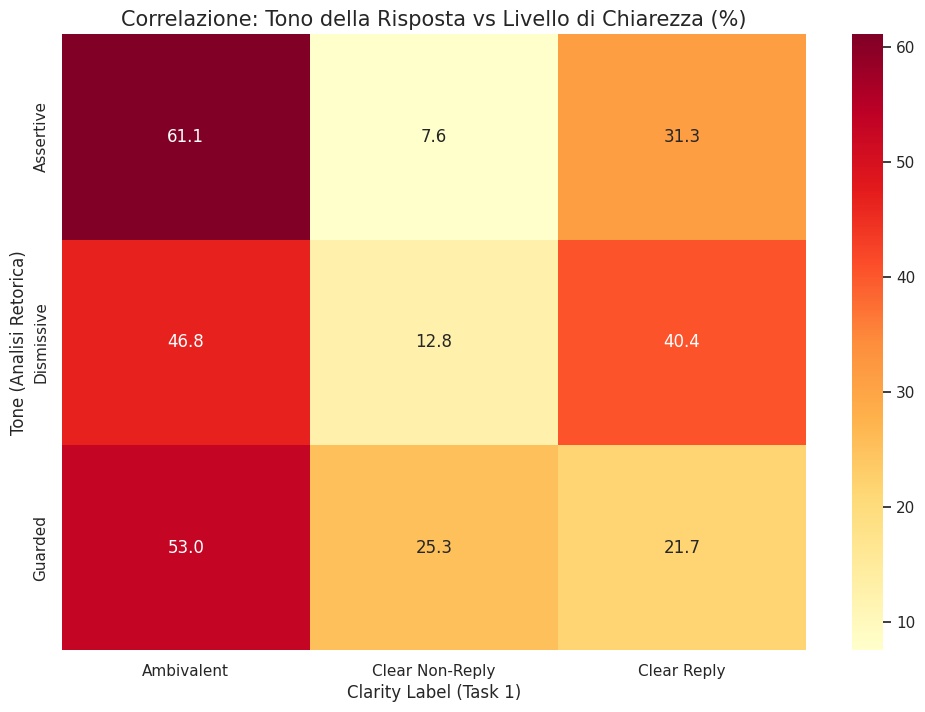

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo la tabella di contingenza (Crosstab)
tone_clarity_crosstab = pd.crosstab(df_all['tone'], df_all['clarity_label'], normalize='index') * 100

# Mostriamo la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlazione: Tono della Risposta vs Livello di Chiarezza (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Analisi Retorica)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Usiamo pd.qcut per dividere in 3 gruppi con lo stesso numero di campioni (terzili)
# labels=["Short", "Medium", "Large"]
df_all['length_category'] = pd.qcut(df_all['word_count_answer'], 3, labels=["Short", "Medium", "Large"])

# Vediamo i range di parole per ogni categoria
bins = pd.qcut(df_all['word_count_answer'], 3, retbins=True)[1]
print(f"Range Short: {bins[0]:.0f} - {bins[1]:.0f} parole")
print(f"Range Medium: {bins[1]:.0f} - {bins[2]:.0f} parole")
print(f"Range Large: {bins[2]:.0f} - {bins[3]:.0f} parole")

Range Short: 1 - 104 parole
Range Medium: 104 - 347 parole
Range Large: 347 - 2117 parole


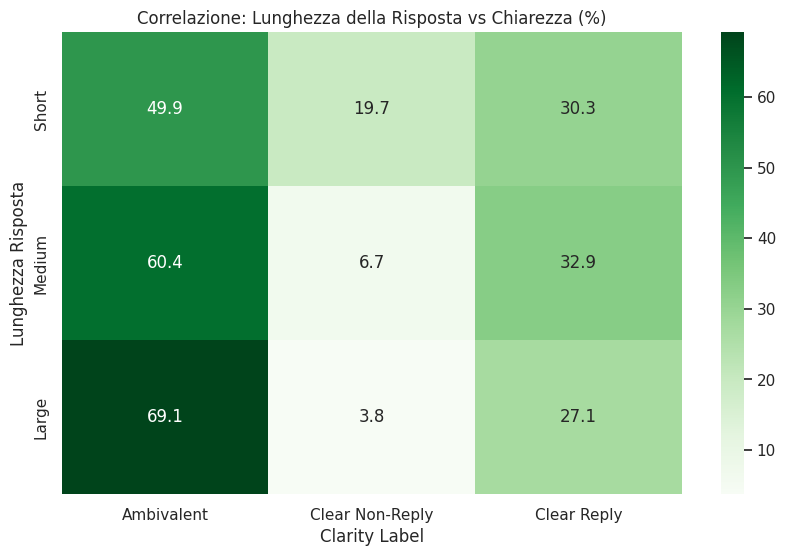

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Crosstab normalizzata per riga
length_clarity_ct = pd.crosstab(df_all['length_category'], df_all['clarity_label'], normalize='index') * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')
plt.title('Correlazione: Lunghezza della Risposta vs Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Lunghezza Risposta')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm.auto import tqdm
import torch

# --- CONFIGURAZIONE ---
TARGET_SIZE = 1100
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. CARICAMENTO MODELLI
print("Caricamento modelli per il ribilanciamento...")

# Modello per il Downsampling (Embeddings)
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Modello per l'Upsampling (Parafrasi) - Caricamento manuale per evitare KeyError
model_para_name = "humarin/chatgpt_paraphraser_on_T5_base"
para_tokenizer = AutoTokenizer.from_pretrained(model_para_name)
para_model = AutoModelForSeq2SeqLM.from_pretrained(model_para_name).to(device)

# 2. SEPARAZIONE CLASSI ORIGINALI
df_ambivalent = df_all[df_all['clarity_label'] == 'Ambivalent'].copy()
df_non_reply = df_all[df_all['clarity_label'] == 'Clear Non-Reply'].copy()
df_reply = df_all[df_all['clarity_label'] == 'Clear Reply'].copy()

# ---------------------------------------------------------
# FASE 1: DOWNSAMPLING SEMANTICO (AMBIVALENT)
# ---------------------------------------------------------
print(f"\n[1/2] Downsampling Ambivalent: Riduzione da {len(df_ambivalent)} a {TARGET_SIZE}...")
# Trasformiamo in vettori
amb_embeddings = embed_model.encode(df_ambivalent['interview_answer'].fillna("").tolist(), show_progress_bar=True)

# Identifichiamo i 1100 "concetti" più rappresentativi
kmeans = KMeans(n_clusters=TARGET_SIZE, random_state=42, n_init=10)
kmeans.fit(amb_embeddings)

# Prendiamo gli esempi reali più vicini ai centri dei gruppi
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, amb_embeddings)
df_ambivalent_reduced = df_ambivalent.iloc[closest].copy()

# ---------------------------------------------------------
# FASE 2: UPSAMPLING PER PARAFRASI (NON-REPLY)
# ---------------------------------------------------------
print(f"\n[2/2] Upsampling Non-Reply: Generazione varianti fino a {TARGET_SIZE}...")

num_needed = TARGET_SIZE - len(df_non_reply)
# Peschiamo casualmente dalle Non-Reply esistenti per generare le basi delle parafrasi
source_samples = df_non_reply.sample(num_needed, replace=True, random_state=42)
texts_to_paraphrase = ["paraphrase: " + str(t) for t in source_samples['interview_answer'].tolist()]

new_answers = []
batch_size = 12 # Numero di parafrasi elaborate insieme in GPU

for i in tqdm(range(0, len(texts_to_paraphrase), batch_size)):
    batch = texts_to_paraphrase[i : i + batch_size]

    # Prepara il testo per il modello
    inputs = para_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

    # Genera la parafrasi
    with torch.no_grad():
        outputs = para_model.generate(**inputs, max_length=128, num_beams=5, early_stopping=True)

    # Converte i numeri in testo
    decoded = para_tokenizer.batch_decode(outputs, skip_special_tokens=True)
    new_answers.extend(decoded)

# Creiamo il dataframe con i dati sintetici
df_non_reply_augmented = source_samples.copy()
df_non_reply_augmented['interview_answer'] = new_answers
df_non_reply_augmented['is_augmented'] = True # Flag per ricordarci che sono dati sintetici

# Uniamo le Non-Reply originali con quelle nuove
df_non_reply_final = pd.concat([df_non_reply, df_non_reply_augmented]).reset_index(drop=True)

# ---------------------------------------------------------
# FASE 3: UNIONE FINALE E SALVATAGGIO
# ---------------------------------------------------------
print("\nFinalizzazione del dataset bilanciato...")
df_final_balanced = pd.concat([
    df_ambivalent_reduced,
    df_non_reply_final,
    df_reply
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- Conteggio Finale delle Classi ---")
print(df_final_balanced['clarity_label'].value_counts())

# Salvataggio su file
df_final_balanced.to_csv("dataset_balanced_ready.csv", index=False)
print("\nDataset bilanciato salvato in: 'dataset_balanced_ready.csv'")

Caricamento modelli per il ribilanciamento...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...


[1/2] Downsampling Ambivalent: Riduzione da 2246 a 1100...


Batches:   0%|          | 0/71 [00:00<?, ?it/s]


[2/2] Upsampling Non-Reply: Generazione varianti fino a 1100...


  0%|          | 0/61 [00:00<?, ?it/s]


Finalizzazione del dataset bilanciato...

--- Conteggio Finale delle Classi ---
clarity_label
Clear Reply        1131
Ambivalent         1100
Clear Non-Reply    1100
Name: count, dtype: int64

Dataset bilanciato salvato in: 'dataset_balanced_ready.csv'


In [ ]:
import pandas as pd
import numpy as np

# Usiamo pd.qcut per dividere in 3 gruppi con lo stesso numero di campioni (terzili)
# labels=["Short", "Medium", "Large"]
df_final_balanced['length_category'] = pd.qcut(df_final_balanced['word_count_answer'], 3, labels=["Short", "Medium", "Large"])

# Vediamo i range di parole per ogni categoria
bins = pd.qcut(df_final_balanced['word_count_answer'], 3, retbins=True)[1]
print(f"Range Short: {bins[0]:.0f} - {bins[1]:.0f} parole")
print(f"Range Medium: {bins[1]:.0f} - {bins[2]:.0f} parole")
print(f"Range Large: {bins[2]:.0f} - {bins[3]:.0f} parole")

Range Short: 1 - 54 parole
Range Medium: 54 - 261 parole
Range Large: 261 - 2117 parole


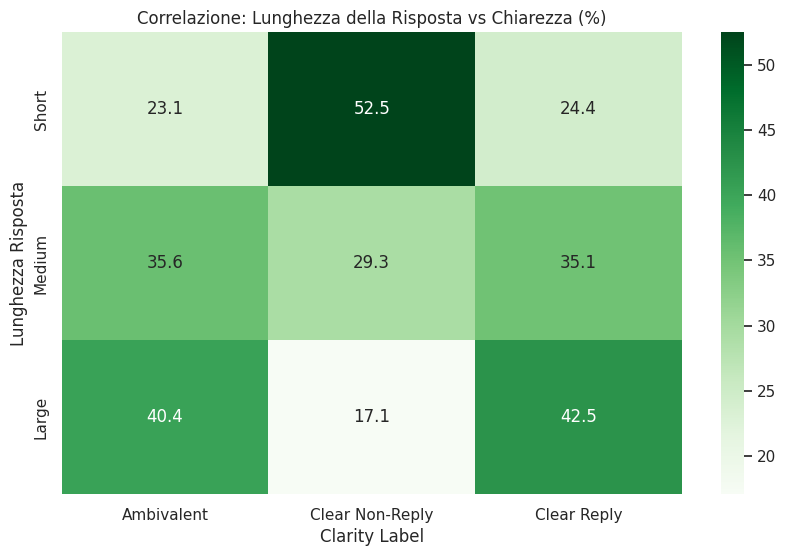

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Crosstab normalizzata per riga
length_clarity_ct = pd.crosstab(df_final_balanced['length_category'], df_final_balanced['clarity_label'], normalize='index') * 100

sns.heatmap(length_clarity_ct, annot=True, fmt='.1f', cmap='Greens')
plt.title('Correlazione: Lunghezza della Risposta vs Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Lunghezza Risposta')
plt.show()

In [ ]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello con FP16 (obbligatorio per velocità su T4)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0,
                      torch_dtype=torch.float16)

candidate_labels = ["Assertive", "Guarded", "Dismissive"]

# 2. Trasformiamo la colonna in un oggetto Dataset di Hugging Face
# Tagliamo a 200 parole per assicurarci che la GPU non si "incanti"
print("Preparazione dati...")
temp_df = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:200]))
})
dataset = Dataset.from_pandas(temp_df)

# 3. Esecuzione con la struttura Dataset + Pipeline + tqdm
results = []
batch_size = 16

print(f"Inizio analisi batch di {len(dataset)} righe...")

for out in tqdm(classifier(KeyDataset(dataset, "text"),
                           candidate_labels=candidate_labels,
                           batch_size=batch_size,
                           truncation=True),
                total=len(dataset)):
    results.append(out['labels'][0])

# 4. Assegnazione finale
df_final_balanced['tone'] = results
print("Analisi completata!")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Preparazione dati...
Inizio analisi batch di 3331 righe...


  0%|          | 0/3331 [00:00<?, ?it/s]

Analisi completata!


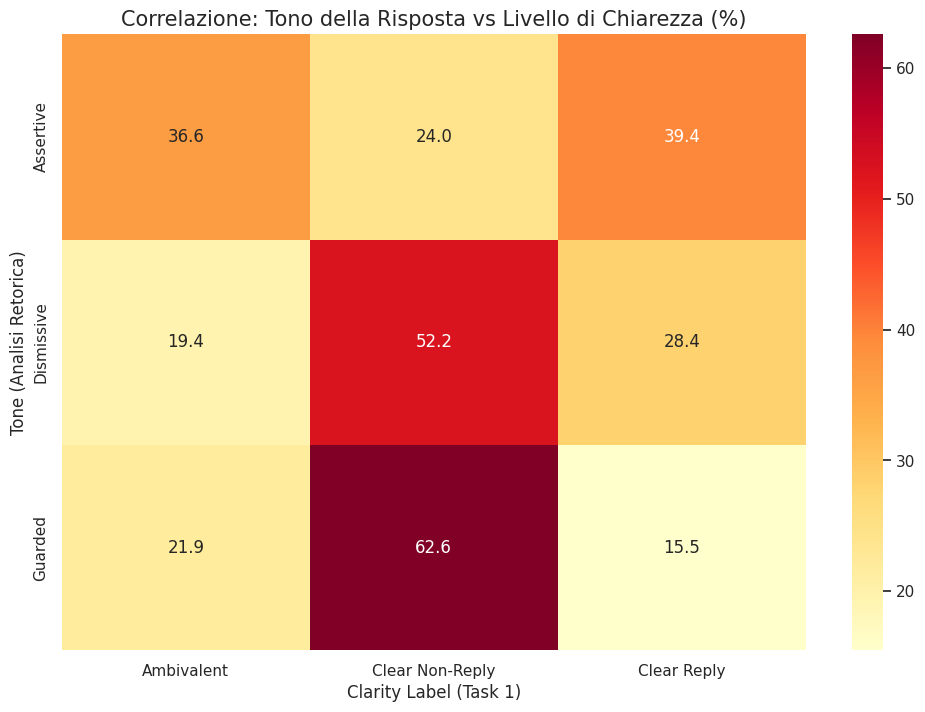

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo la tabella di contingenza (Crosstab)
tone_clarity_crosstab = pd.crosstab(df_final_balanced['tone'], df_final_balanced['clarity_label'], normalize='index') * 100

# Mostriamo la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tone_clarity_crosstab, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Correlazione: Tono della Risposta vs Livello di Chiarezza (%)', fontsize=15)
plt.xlabel('Clarity Label (Task 1)', fontsize=12)
plt.ylabel('Tone (Analisi Retorica)', fontsize=12)

plt.savefig(f"{ANALYSIS_DIR}/balanced_heatmap_tone_clarity_4.png", bbox_inches='tight')
plt.show()

In [ ]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from datasets import Dataset
import pandas as pd
from tqdm.auto import tqdm

# 1. Inizializzazione modello Emotion (Veloce e accurato)
emotion_classifier = pipeline("text-classification",
                              model="j-hartmann/emotion-english-distilroberta-base",
                              device=0 if torch.cuda.is_available() else -1,
                              top_k=1) # Vogliamo solo l'emozione principale

# 2. Prepariamo il Dataset (Taglio a 100 parole per coerenza e velocità)
print("Preparazione dati per Emotion Recognition...")
temp_df_emotion = pd.DataFrame({
    "text": df_final_balanced['interview_answer'].fillna("Unknown").apply(lambda x: " ".join(str(x).split()[:100]))
})
dataset_emotion = Dataset.from_pandas(temp_df_emotion)

# 3. Esecuzione Batch
emotion_results = []
batch_size = 16

print(f"Inizio analisi emozioni su {len(dataset_emotion)} righe...")

for out in tqdm(emotion_classifier(KeyDataset(dataset_emotion, "text"),
                                   batch_size=batch_size,
                                   truncation=True),
                total=len(dataset_emotion)):
    # out è una lista di liste perché abbiamo usato top_k=1
    emotion_results.append(out[0]['label'])

df_final_balanced['emotion'] = emotion_results
print("Analisi emozioni completata!")

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Preparazione dati per Emotion Recognition...
Inizio analisi emozioni su 3331 righe...


  0%|          | 0/3331 [00:00<?, ?it/s]

Analisi emozioni completata!


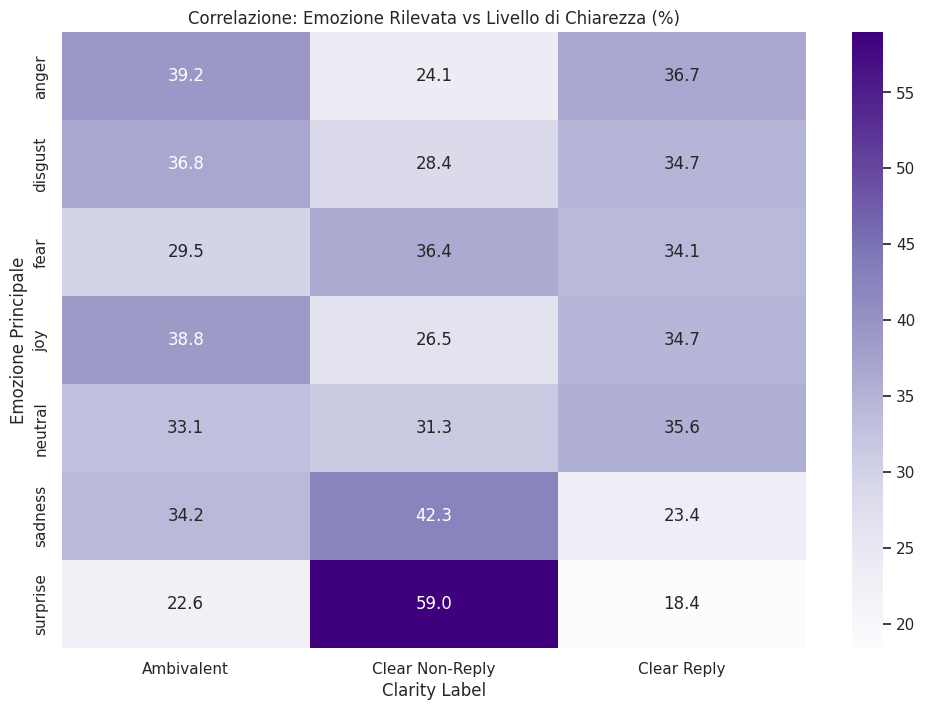

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Crosstab tra emozioni e clarity_label
emotion_ct = pd.crosstab(df_final_balanced['emotion'], df_final_balanced['clarity_label'], normalize='index') * 100

sns.heatmap(emotion_ct, annot=True, fmt='.1f', cmap='Purples')
plt.title('Correlazione: Emozione Rilevata vs Livello di Chiarezza (%)')
plt.xlabel('Clarity Label')
plt.ylabel('Emozione Principale')
plt.show()